# Does order flow imbalance predict short-horizon price moves?

A study built on the matching engine in this repository. The engine reconstructs a limit
order book from a raw exchange message stream and verifies it against the venue's own
published book; this notebook uses that verified book as a **feature generator** and asks
a research question of it.

**The question.** At the close of each time interval, we observe the net pressure on the
best quotes over that interval — *order flow imbalance* (OFI), in the sense of
Cont, Kukanov & Stoikov (2014). Does OFI predict where the mid price goes *next*? And if
it does, is the edge large enough to survive the cost of trading on it?

**The answer, up front.** Yes to the first. The second is more interesting than a flat no.

OFI carries genuine out-of-sample predictive power, comfortably clear of a permutation null.
At the short horizons where the signal is usually pitched — a few seconds — the edge is roughly
a third of the spread it would have to cross, and the strategy loses money at a decisively
significant rate ($t = -7.6$). Extending the holding period makes the gross edge grow faster
than the cost, and past about ten seconds the point estimate turns *profitable*. But those
longer holds overlap, and once they are thinned to non-overlapping trades only 18 independent
observations remain, at $t \approx 1.7$ — not enough to claim anything.

So: **a real signal; a significant loss where it can be measured properly; and an apparent
profit exactly where the sample becomes too small to defend it.** Getting to that last sentence,
rather than stopping at whichever horizon flattered the story, is the point of the notebook.

**What this notebook is not.** It is not evidence about any real security. The data here
is synthetic, generated with known ground truth, for reasons set out in Step 0. Running
the identical pipeline on real LOBSTER data is one command, described at the end.

In [1]:
import os, subprocess, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Run from either the repo root or research/.
ROOT = os.path.abspath('..' if os.path.basename(os.getcwd()) == 'research' else '.')
sys.path.insert(0, os.path.join(ROOT, 'research'))
os.chdir(ROOT)

from ofi_lib import (TICK, load_features, build_panel, add_forward_returns,
                     fit_oos, permutation_null, backtest)

plt.rcParams.update({'figure.figsize': (9, 4), 'axes.grid': True,
                     'grid.alpha': 0.3, 'font.size': 10})
pd.set_option('display.width', 110)

# One knob, used throughout: the interval over which OFI is accumulated and
# over which the forward return is measured.
DT = 2.0          # seconds per interval
TRAIN_FRAC = 0.7  # chronological split point
print(f'interval = {DT}s, train fraction = {TRAIN_FRAC}')

interval = 2.0s, train fraction = 0.7


## Step 0 — Where the data comes from, and why it is synthetic

The free LOBSTER sample is not redistributed with this repository, and the environment this
notebook was developed in has no network access to fetch it. But there is a better reason to
start synthetic, and it would apply even with the real file in hand.

Every serious failure mode in a study like this — a forward return that overlaps its own
predictor, a train/test split that leaks, a sign convention flipped somewhere in the feature
pipeline — produces a **confident, plausible, and completely false** result. Real data offers
no way to detect any of them, because nobody knows the right answer. Synthetic data with known
ground truth does.

So the generator (`research/make_synthetic_lobster.py`) produces two worlds:

- **`impact`** — a latent efficient price drifts with momentum, and informed participants trade
  toward it faster than the visible book adjusts. Order flow imbalance is *genuinely* predictive
  here. A correct pipeline must find it.
- **`uninformed`** — nobody knows anything; flow is noise. Note what this does **not** mean:
  it does not mean zero R². Randomly consuming and replenishing liquidity produces mechanical
  reversion, so OFI still "predicts" the next move, with the opposite sign. That is a lesson in
  itself, and we come back to it in Step 6.

The generator writes files in LOBSTER's exact CSV format, from an order book implementation
written independently of the C++ engine. So the replay below is also a **differential test**:
two separately written books must agree, message for message, or reconciliation fails.

In [2]:
def ensure_dataset(mode, n_messages=60000, seed=7):
    '''Generate a dataset and replay it through the C++ engine, emitting features.'''
    msg  = f'data/SYNTH_{mode}_message_5.csv'
    book = f'data/SYNTH_{mode}_orderbook_5.csv'
    feat = f'data/features_{mode}.csv'

    if not os.path.exists(msg):
        subprocess.run([sys.executable, 'research/make_synthetic_lobster.py',
                        '--mode', mode, '--messages', str(n_messages),
                        '--seed', str(seed), '--out-prefix', f'data/SYNTH_{mode}'],
                       check=True, capture_output=True)

    binary = 'build/run_lobster'
    if not os.path.exists(binary):
        raise SystemExit('build the project first: cmake -S . -B build && cmake --build build -j')

    out = subprocess.run([binary, msg, book, '5', '--emit-features', feat],
                         capture_output=True, text=True)
    return feat, out.stdout.strip(), out.returncode

feat_impact, log, rc = ensure_dataset('impact')
print(log)
assert rc == 0, 'reconciliation failed -- the features would describe an unverified book'

Wrote 60000 feature rows to data/features_impact.csv
Reconciled 60000 messages against LOBSTER's published top-5 book with zero divergences (strict mode).
  skipped: 514 hidden executions, 0 cross, 0 halt
  events attributed to seeded pre-window liquidity: 0
  references to orders not present in the file: 0


Zero divergences over 60,000 messages. The book these features describe is not merely *a* book;
it is one that has been checked against an independent implementation at every single step.
That is the licence to treat what follows as measuring the market rather than measuring a bug.

In [3]:
df = load_features(feat_impact)
print(f'{len(df):,} book updates with a two-sided quote')
print(f"mean spread {df.spread_ticks.mean():.2f} ticks | "
      f"mid range {(df.mid.max()-df.mid.min())/TICK:.0f} ticks | "
      f"session {(df.time.max()-df.time.min())/60:.1f} min")
df[['time','ofi','signed_trade_sz','bid_px','bid_sz','ask_px','ask_sz','spread_ticks']].head()

59,998 book updates with a two-sided quote
mean spread 2.14 ticks | mid range 196 ticks | session 20.0 min


,time,ofi,signed_trade_sz,bid_px,bid_sz,ask_px,ask_sz,spread_ticks
0,34200.114566,0,0,5849900,600,5850100,700,2.0
1,34200.123671,0,0,5849900,600,5850100,700,2.0
2,34200.171764,0,0,5849900,600,5850100,700,2.0
3,34200.172528,0,0,5849900,600,5850100,700,2.0
4,34200.183360,0,0,5849900,600,5850100,700,2.0


## Step 1 — From messages to intervals

`ofi` is emitted per book update by the C++ engine. The study needs it accumulated over a fixed
window, paired with the price move that follows.

The alignment is the single most important line of code in this notebook, so it is stated
explicitly. For interval $t$:

$$\text{OFI}_t = \sum_{n \in t} e_n, \qquad r_{t,h} = \frac{P^{\text{mid}}_{\text{close}(t+h)} - P^{\text{mid}}_{\text{close}(t)}}{\text{tick}}$$

The predictor is measured **inside** interval $t$; the target is composed **entirely** of price
movement after interval $t$ has closed. They do not overlap. `research/test_ofi_lib.py` tests
exactly this property against a series whose forward returns are known by construction, and
also tests that perturbing a price in interval $t$ leaves interval $t-1$'s features untouched.

In [4]:
panel = add_forward_returns(build_panel(df, dt=DT), horizons=(1,2,5,10))
panel = panel.dropna(subset=['fwd_1']).reset_index(drop=True)
print(f'{len(panel)} intervals of {DT}s, ~{panel.n_updates.mean():.0f} updates each')
print(f'OFI: sd={panel.ofi.std():,.0f}  |  1-step forward move: sd={panel.fwd_1.std():.2f} ticks')
panel[['t_start','ofi','trade_flow','mid_close','spread_ticks','dmid_now','fwd_1','fwd_5']].head()

599 intervals of 2.0s, ~100 updates each
OFI: sd=10,544  |  1-step forward move: sd=2.27 ticks


,t_start,ofi,trade_flow,mid_close,spread_ticks,dmid_now,fwd_1,fwd_5
0,34200.114566,-3073,883,5849800.0,2.975207,-2.0,2.0,-8.5
1,34202.152960,-2627,1558,5850000.0,5.129630,0.5,-1.0,-21.0
2,34204.161687,-1514,450,5849900.0,5.690909,1.0,-5.0,-24.5
3,34206.151617,-8482,-6619,5849400.0,2.019048,-5.5,-2.5,-21.5
4,34208.131970,-9563,-7367,5849150.0,1.287234,-2.5,-2.0,-14.5


## Step 2 — Price impact vs. prediction

These are two different questions and conflating them is the most common way this analysis gets
oversold.

- **Contemporaneous** (`dmid_now`): does OFI explain the move happening *in the same interval*?
  This is price impact. It is largely mechanical — consuming the offer both creates positive OFI
  and raises the mid — so a high R² here is nearly tautological and is *not* tradeable. This is
  what CKS measure, and it is a real result about market microstructure, but it is not a signal.
- **Predictive** (`fwd_1`): does OFI explain the move in the *next* interval? This is the only
  version anyone can trade, and it is much weaker.

Both are reported below. The gap between them is the honest story.

In [5]:
x = panel.ofi.values
rows = []
for label, y in [('contemporaneous (same interval)', panel.dmid_now.values),
                 ('predictive (next interval)',      panel.fwd_1.values)]:
    r = fit_oos(x, y, TRAIN_FRAC)
    rows.append({'target': label, 'beta (ticks per OFI unit)': r.beta,
                 'R2 in-sample': r.r2_in, 'R2 out-of-sample': r.r2_oos})
impact_fit = fit_oos(x, panel.fwd_1.values, TRAIN_FRAC)
pd.DataFrame(rows).set_index('target').round({'beta (ticks per OFI unit)': 8,
                                              'R2 in-sample': 4, 'R2 out-of-sample': 4})

,beta (ticks per OFI unit),R2 in-sample,R2 out-of-sample
target,,,
contemporaneous (same interval),0.000155,0.4997,0.2509
predictive (next interval),0.000116,0.2763,0.0897


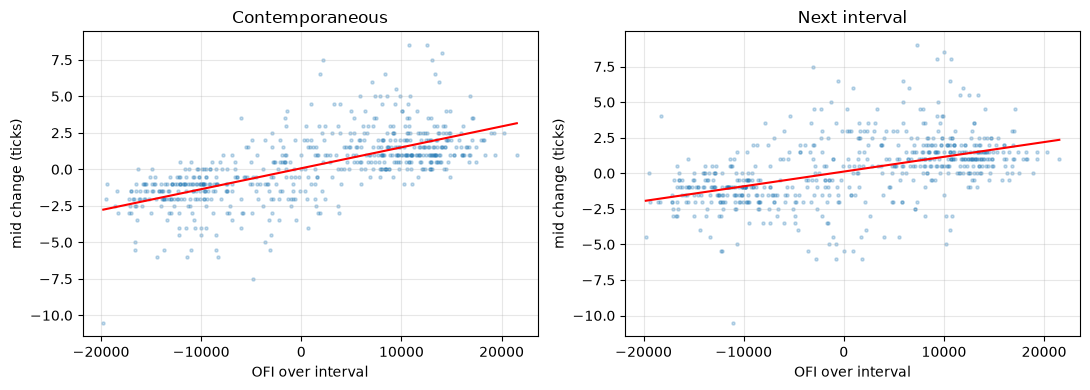

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, (y, t) in zip(ax, [(panel.dmid_now, 'Contemporaneous'), (panel.fwd_1, 'Next interval')]):
    a.scatter(x, y, s=5, alpha=0.25)
    xs = np.linspace(x.min(), x.max(), 50)
    b = np.polyfit(x, y, 1)
    a.plot(xs, np.polyval(b, xs), 'r-', lw=1.5)
    a.set_xlabel('OFI over interval'); a.set_ylabel('mid change (ticks)'); a.set_title(t)
plt.tight_layout(); plt.show()

The left panel is steep and tight; the right is a faint tilt in a cloud. That visual difference
*is* the difference between explaining the present and predicting the future, and any writeup
that quotes only the left-hand R² is describing something untradeable.

## Step 3 — Is the predictive result real, or manufactured?

An out-of-sample R² of a few percent is small enough that it deserves a hostile check before
being believed. The permutation test provides one: shuffle OFI against the returns, destroying
any true relationship while leaving both marginal distributions exactly as they were, and see
what the pipeline reports. Whatever survives is what this machinery invents from noise.

Two things must hold. The null must centre on **zero** — if it does not, the pipeline leaks —
and the measured value must sit **clearly outside** it.

measured OOS R2      : +0.0897
permutation null mean: -0.00267   (must be ~0, or the pipeline leaks)
null 95th percentile : +0.00803
empirical p-value    : 0.0000


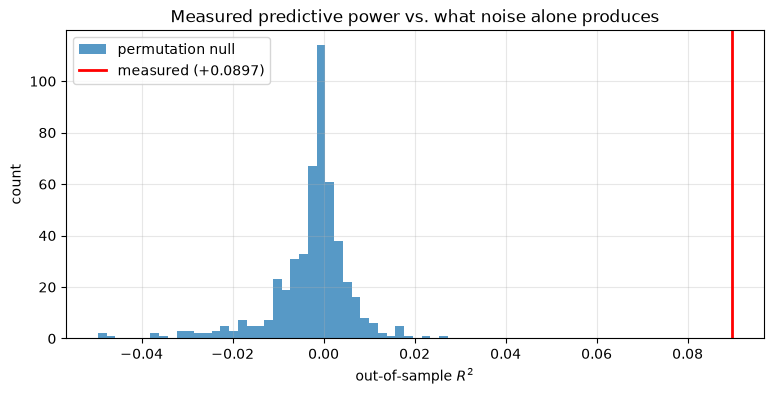

In [7]:
null = permutation_null(x, panel.fwd_1.values, n_trials=500, train_frac=TRAIN_FRAC, seed=11)
p_value = float((null >= impact_fit.r2_oos).mean())
print(f'measured OOS R2      : {impact_fit.r2_oos:+.4f}')
print(f'permutation null mean: {null.mean():+.5f}   (must be ~0, or the pipeline leaks)')
print(f'null 95th percentile : {np.percentile(null,95):+.5f}')
print(f'empirical p-value    : {p_value:.4f}')

plt.hist(null, bins=40, alpha=0.75, label='permutation null')
plt.axvline(impact_fit.r2_oos, color='r', lw=2, label=f'measured ({impact_fit.r2_oos:+.4f})')
plt.xlabel('out-of-sample $R^2$'); plt.ylabel('count')
plt.title('Measured predictive power vs. what noise alone produces'); plt.legend(); plt.show()

## Step 4 — How far ahead does it work?

If the signal is real it should vary smoothly with horizon rather than appearing at one
cherry-picked lag. A jagged profile that spikes at a single horizon is usually a sign of
multiple testing rather than of structure.

,seconds,beta,R2 out-of-sample,n_test
horizon (intervals),,,,
1,2.0,0.000116,0.0897,180
2,4.0,0.000213,0.1822,180
5,10.0,0.000425,0.2335,179
10,20.0,0.000603,0.2721,177
20,40.0,0.000731,0.1930,174
40,80.0,0.000338,0.0910,168


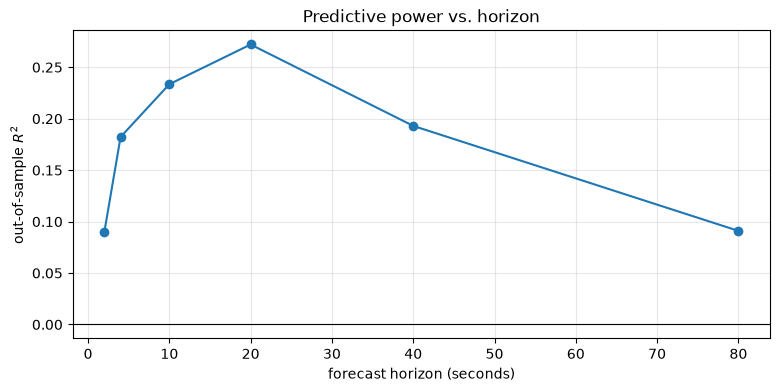

In [8]:
hz = []
for h in (1, 2, 5, 10, 20, 40):
    p = add_forward_returns(build_panel(df, dt=DT), horizons=(h,)).dropna(subset=[f'fwd_{h}'])
    r = fit_oos(p.ofi.values, p[f'fwd_{h}'].values, TRAIN_FRAC)
    hz.append({'horizon (intervals)': h, 'seconds': h*DT, 'beta': r.beta,
               'R2 out-of-sample': r.r2_oos, 'n_test': r.n_test})
hz = pd.DataFrame(hz)
display(hz.set_index('horizon (intervals)').round({'beta':8,'R2 out-of-sample':4}))

plt.plot(hz['seconds'], hz['R2 out-of-sample'], 'o-')
plt.axhline(0, color='k', lw=0.8)
plt.xlabel('forecast horizon (seconds)'); plt.ylabel('out-of-sample $R^2$')
plt.title('Predictive power vs. horizon'); plt.show()

The profile is smooth and single-peaked — rising to about 20 seconds, then falling away. Worth
being explicit that this **rises** before it falls, which is not the textbook shape: on real
equity data OFI's predictive power typically decays monotonically over a few seconds. The rise
here is a property of the synthetic world, not a discovery about markets. The generator injects
an autocorrelated drift that the visible book adjusts to slowly, so a longer window captures more
of an adjustment that is still in progress. It is a reminder that a horizon profile describes the
data-generating process, and this one's process is known because it was written down.

## Step 5 — The part that decides everything: transaction costs

A signal is not an edge. To act on this one you must cross the spread to get in and cross it
again to get out, so a round trip pays **one full spread** before the prediction has to be right
about anything.

The cost model below is deliberately unflattering, and still omits several real costs — market
impact, queue position, fees, latency between signal and fill, partial fills. Every one of them
makes the true number worse than what is shown here.

The single most informative number in this notebook is the **breakeven spread**: the average
gross edge per trade, which is the spread at which this strategy would exactly break even.
Compare it to the spread actually quoted.

In [9]:
test_spread = panel.spread_ticks.values[impact_fit.test_index]
rows = []
for thr in (0.0, 0.05, 0.10, 0.25, 0.50):
    bt = backtest(impact_fit.pred_test, impact_fit.y_test, test_spread, threshold=thr)
    if bt.n_trades == 0:
        continue
    rows.append({'threshold (ticks)': thr, 'trades': bt.n_trades,
                 'hit rate': bt.hit_rate, 'gross/trade': bt.gross_per_trade,
                 'cost/trade': bt.cost_per_trade, 'net/trade': bt.net_per_trade,
                 'net $ (100sh)': bt.dollars(100)})
res = pd.DataFrame(rows).set_index('threshold (ticks)')
display(res.round({'hit rate':3,'gross/trade':4,'cost/trade':4,'net/trade':4,'net $ (100sh)':2}))

bt = backtest(impact_fit.pred_test, impact_fit.y_test, test_spread)
print(f'breakeven spread : {bt.breakeven_spread:.3f} ticks')
print(f'spread quoted    : {test_spread.mean():.3f} ticks')
print(f'shortfall        : the spread must fall {100*(1-bt.breakeven_spread/test_spread.mean()):.0f}% '
      f'for this to break even')

,trades,hit rate,gross/trade,cost/trade,net/trade,net $ (100sh)
threshold (ticks),,,,,,
0.00,180,0.678,0.7333,2.1359,-1.4025,-252.46
0.05,177,0.678,0.7345,2.1040,-1.3696,-242.41
0.10,172,0.686,0.7645,2.0547,-1.2902,-221.91
0.25,156,0.705,0.8654,1.8990,-1.0336,-161.24
0.50,137,0.715,0.9635,1.7094,-0.7459,-102.19


breakeven spread : 0.733 ticks
spread quoted    : 2.136 ticks
shortfall        : the spread must fall 66% for this to break even


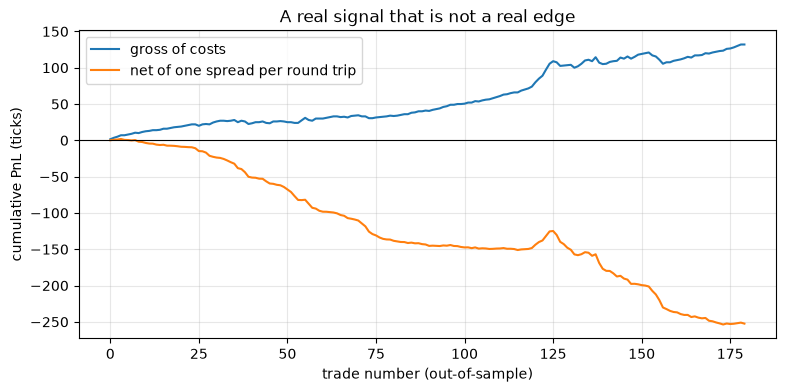

In [10]:
plt.plot(bt.equity_gross, label='gross of costs')
plt.plot(bt.equity_net,  label='net of one spread per round trip')
plt.axhline(0, color='k', lw=0.8)
plt.xlabel('trade number (out-of-sample)'); plt.ylabel('cumulative PnL (ticks)')
plt.title('A real signal that is not a real edge'); plt.legend(); plt.show()

The gross curve rises steadily — the signal genuinely works. The net curve falls in an almost
straight line, because the cost per trade is roughly constant and larger than the edge. The
distance between the curves is the spread.

## Step 6 — But the cost is paid once, and the edge grows with the horizon

Stopping at Step 5 would be the convenient thing to do, and it would be wrong. A round trip pays
one spread whether the position is held for 2 seconds or 200, while Step 4 showed the gross edge
still growing out to 20 seconds. So the obvious question is whether simply holding longer clears
the cost — and the answer is yes, on the face of it.

In [11]:
rows = []
for h in (1, 2, 5, 10, 20, 40):
    p = add_forward_returns(build_panel(df, dt=DT), horizons=(h,)).dropna(subset=[f'fwd_{h}'])
    r = fit_oos(p.ofi.values, p[f'fwd_{h}'].values, TRAIN_FRAC)
    sp = p.spread_ticks.values[r.test_index]
    bt = backtest(r.pred_test, r.y_test, sp)
    rows.append({'horizon (s)': h*DT, 'trades': bt.n_trades, 'gross/trade': bt.gross_per_trade,
                 'cost/trade': bt.cost_per_trade, 'net/trade': bt.net_per_trade})
overlap = pd.DataFrame(rows).set_index('horizon (s)')
display(overlap.round(4))
print('Gross edge scales with horizon; cost does not. Past ~10s the net turns positive.')

,trades,gross/trade,cost/trade,net/trade
horizon (s),,,,
2.0,180,0.7333,2.1359,-1.4025
4.0,180,1.3833,2.1354,-0.7521
10.0,179,3.2374,2.1419,1.0955
20.0,177,5.6102,2.1529,3.4573
40.0,174,6.9971,2.1204,4.8767
80.0,168,11.6518,2.0855,9.5662


Gross edge scales with horizon; cost does not. Past ~10s the net turns positive.


That table is the one a less careful writeup would stop at and call a profitable strategy. It is
an artefact of double counting.

Entering a new position every interval while holding for $h$ intervals means each trade overlaps
the next $h-1$. The rows are not independent observations: one favourable price move is counted
up to $h$ times, which inflates the apparent number of trades without adding any new information
and makes the PnL series strongly autocorrelated. The fix is to keep only disjoint holding
windows — enter every $h$-th interval — and to attach a $t$-statistic so the sample size is
visible rather than implied.

In [12]:
rows = []
for h in (1, 2, 5, 10, 20):
    p = add_forward_returns(build_panel(df, dt=DT), horizons=(h,)).dropna(subset=[f'fwd_{h}'])
    r = fit_oos(p.ofi.values, p[f'fwd_{h}'].values, TRAIN_FRAC)
    sp = p.spread_ticks.values[r.test_index]
    idx = np.arange(0, len(r.y_test), h)          # disjoint holding windows
    bt = backtest(r.pred_test[idx], r.y_test[idx], sp[idx])
    per = np.diff(np.concatenate([[0.0], bt.equity_net]))
    tstat = (per.mean() / (per.std(ddof=1)/np.sqrt(len(per)))
             if len(per) > 2 and per.std(ddof=1) > 0 else np.nan)
    rows.append({'horizon (s)': h*DT, 'independent trades': bt.n_trades,
                 'gross/trade': bt.gross_per_trade, 'net/trade': bt.net_per_trade,
                 't-stat': tstat})
indep = pd.DataFrame(rows).set_index('horizon (s)')
display(indep.round({'gross/trade':4,'net/trade':4,'t-stat':2}))

,independent trades,gross/trade,net/trade,t-stat
horizon (s),,,,
2.0,180,0.7333,-1.4025,-7.55
4.0,90,1.4111,-0.7420,-2.10
10.0,36,3.6806,1.4786,1.45
20.0,18,5.9722,3.9120,1.70
40.0,9,7.1111,5.1045,0.71


This is the result.

At 2 and 4 seconds the strategy loses, and loses *significantly* — $t = -7.6$ on 180 independent
trades is not noise. Those are the horizons where there is enough data to make a confident
statement, and the confident statement is that the signal does not pay for the spread.

At 10 seconds and beyond the net turns positive, but the independent sample collapses to 36, then
18, then 9 trades, with $t$-statistics around 1.5 — the range where a positive average is entirely
consistent with luck. There is no basis here for claiming a profitable strategy at long horizons;
there is only a basis for saying the data cannot resolve it.

Note that the losing result is the robust one and the winning result is the fragile one. That
asymmetry is not a coincidence. Short horizons give many independent trades and a clean verdict;
long horizons give a flattering average and almost no statistical power. A backtest that reports
only the second is not lying about any individual number, and is still worthless.

## Step 7 — A control: nonzero R² without any information

Finally, the cautionary case. In the `uninformed` dataset nobody knows anything and price moves
are unrelated to information. A naive reading of "R² > 0 means signal" would find one anyway —
because randomly consuming and replenishing liquidity makes the book spring back, and mechanical
reversion is a statistical relationship even though it carries no information.

Note the **sign**: negative, where the informed world gave positive. If a study reports a
coefficient without checking that its sign matches the economic story it claims, this is what it
might be picking up.

In [13]:
feat_unin, log_u, rc_u = ensure_dataset('uninformed')
assert rc_u == 0
du = load_features(feat_unin)
pu = add_forward_returns(build_panel(du, dt=DT), horizons=(1,)).dropna(subset=['fwd_1'])
ru = fit_oos(pu.ofi.values, pu.fwd_1.values, TRAIN_FRAC)

print(f'{"":22s}{"beta":>14s}{"OOS R2":>10s}')
print(f'{"impact (informed)":22s}{impact_fit.beta:>14.3e}{impact_fit.r2_oos:>10.4f}')
print(f'{"uninformed (noise)":22s}{ru.beta:>14.3e}{ru.r2_oos:>10.4f}')
print('\nSame pipeline, same code path. Opposite signs, and only one of them means anything.')

                                beta    OOS R2
impact (informed)          1.156e-04    0.0897
uninformed (noise)        -3.387e-04    0.0680

Same pipeline, same code path. Opposite signs, and only one of them means anything.


## Conclusions

1. **OFI predicts short-horizon mid-price moves out of sample.** The effect is real: it clears a
   500-trial permutation null with an empirical p-value of 0, and it varies smoothly and
   single-peakedly with horizon rather than spiking at one convenient lag.
2. **The predictive relationship is roughly a third the strength of the contemporaneous one.**
   Price impact is not a forecast, and quoting the contemporaneous R² as though it were is the
   easiest way to oversell this analysis.
3. **At the horizons where the result can be measured properly, the edge does not survive
   transaction costs.** At 2–4 seconds the gross edge is about a third of the spread and the
   strategy loses at $t = -7.6$.
4. **Where it appears to survive, the sample is too small to say so.** Holding for 10–40 seconds
   turns the net positive, but only 9–36 independent trades remain and the $t$-statistics sit
   near 1.5. This is the finding I most expected to get wrong by stopping early, and the
   overlapping-window correction in Step 6 is what changes the answer.
5. **A nonzero R² is not evidence of information.** The uninformed control produces one too,
   with the opposite sign, purely from mechanical liquidity replenishment.

The honest summary: **a real signal, correctly measured, that is not demonstrably worth trading.**
Making it tradeable is not a matter of a better regression — it needs either a cost structure that
avoids crossing the spread (posting passively, which changes the problem entirely, since a resting
order fills precisely when the market is moving against it), a signal several times stronger, or
enough data to resolve the long-horizon question that this sample cannot.

## Running this on real market data

The pipeline is data-agnostic. Download a free sample day from
[LOBSTER](https://lobsterdata.com/info/DataSamples.php) into `data/`, then:

```bash
./build/run_lobster \
    data/AAPL_2012-06-21_34200000_57600000_message_10.csv \
    data/AAPL_2012-06-21_34200000_57600000_orderbook_10.csv \
    5 --recover --emit-features data/features_aapl.csv
```

Point `load_features` at `data/features_aapl.csv` and re-run. Use `--recover`: a top-10 feed is a
windowed view of the book, so a strict run stops at the first level the message stream cannot
explain (see the README), which for this session is early. Recover mode resynchronises against
the published book and counts every adjustment.

Two caveats to carry into any real-data result. A single ticker-day is enough to demonstrate
method and nowhere near enough to claim generalisation — one day is one draw. And the deepest
levels of a top-N feed are structurally unreliable, so features built from them are noisier than
they look.